In [1]:
import pandas as pd

df = pd.read_csv('../data/Sample_Superstore.csv', encoding='ISO-8859-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
df.shape

(9994, 21)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
print(df['Category'].unique())
print(df['Sub-Category'].unique())
print(df['Region'].unique())
print(df['Ship Mode'].unique())

<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str
<StringArray>
[  'Bookcases',      'Chairs',      'Labels',      'Tables',     'Storage',
 'Furnishings',         'Art',      'Phones',     'Binders',  'Appliances',
       'Paper', 'Accessories',   'Envelopes',   'Fasteners',    'Supplies',
    'Machines',     'Copiers']
Length: 17, dtype: str
<StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str
<StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str


In [8]:
# Compara la longitud del texto original vs sin espacios
for cat in df['Sub-Category'].unique():
    if cat != cat.strip():
        print(f"Espacio detectado en: '{cat}'")

In [9]:
transacciones_con_perdida = df[df['Profit'] < 0]
print(f"Transacciones con perdida: {transacciones_con_perdida.shape[0]}")
print(f"Porcentaje del total: {transacciones_con_perdida.shape[0] / df.shape[0] * 100:.1f}%")

Transacciones con perdida: 1871
Porcentaje del total: 18.7%


In [10]:
descuento_con_perdida = df[df['Profit'] < 0]['Discount'].mean()
descuento_sin_perdida = df[df['Profit'] >= 0]['Discount'].mean()

print(f"Descuento promedio EN transacciones con perdida: {descuento_con_perdida:.2%}")
print(f"Descuento promedio EN transacciones SIN perdida: {descuento_sin_perdida:.2%}")

Descuento promedio EN transacciones con perdida: 48.09%
Descuento promedio EN transacciones SIN perdida: 8.14%


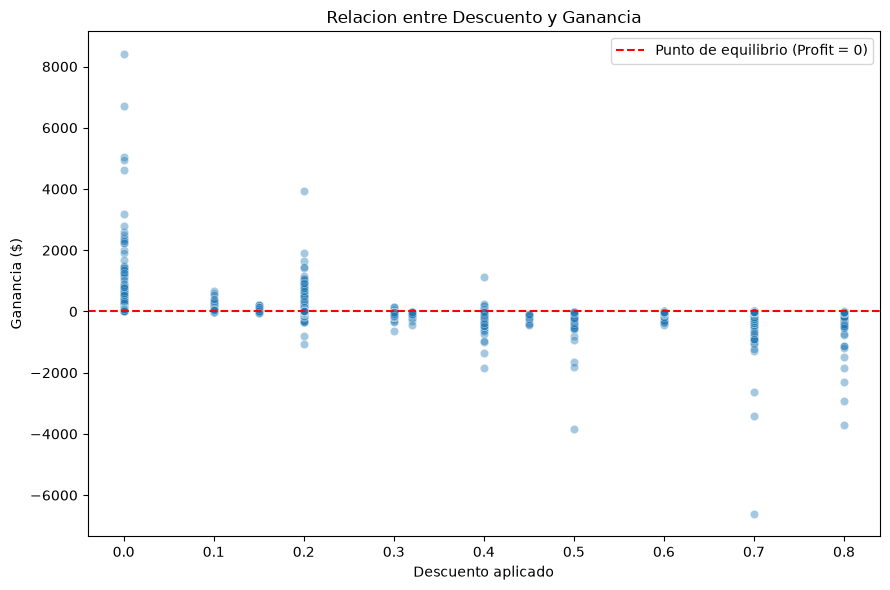

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4)
plt.axhline(0, color='red', linestyle='--', label='Punto de equilibrio (Profit = 0)')
plt.title('Relacion entre Descuento y Ganancia')
plt.xlabel('Descuento aplicado')
plt.ylabel('Ganancia ($)')
plt.legend()
plt.tight_layout()
plt.show()

## Hallazgo: Los descuentos altos generan perdidas sistematicas

El 18.7% de las transacciones (1,871 de 9,994) generan perdida para el negocio. 
Existe una relacion clara entre el descuento aplicado y la rentabilidad:

- Transacciones con perdida: descuento promedio de 48.09%
- Transacciones rentables: descuento promedio de 8.14%

El grafico de dispersion muestra que, a partir de un descuento aproximado del 50%, 
casi la totalidad de las transacciones resultan en perdida. Esto sugiere que la 
politica de descuentos del negocio (o al menos los descuentos superiores al 40-50%) 
deberia ser revisada, ya que consistentemente erosiona la rentabilidad.

In [12]:
ganancia_total_por_categoria = df.groupby('Category')['Profit'].sum()
ganancia_total_por_categoria

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

In [13]:
ventas_totales_por_categoria = df.groupby('Category')['Sales'].sum()
print(ventas_totales_por_categoria)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


In [14]:
margen_por_categoria = (ganancia_total_por_categoria / ventas_totales_por_categoria) * 100
print(margen_por_categoria)

Category
Furniture           2.486695
Office Supplies    17.035158
Technology         17.395712
dtype: float64


In [15]:
descuento_promedio_por_categoria = df.groupby('Category')['Discount'].mean()
print(descuento_promedio_por_categoria)

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64


In [16]:
solo_furniture = df[df['Category'] == 'Furniture']

margen_sub = solo_furniture.groupby('Sub-Category').apply(
    lambda x: (x['Profit'].sum() / x['Sales'].sum()) * 100
)
print(margen_sub)

Sub-Category
Bookcases      -3.022768
Chairs          8.095673
Furnishings    14.240358
Tables         -8.564460
dtype: float64


In [17]:
descuento_sub = solo_furniture.groupby('Sub-Category')['Discount'].mean()
print(descuento_sub)

Sub-Category
Bookcases      0.211140
Chairs         0.170178
Furnishings    0.138349
Tables         0.261285
Name: Discount, dtype: float64


## Hallazgo: La perdida en Furniture esta concentrada en Tables

La categoria Furniture tiene el margen mas bajo en general (2.49%), pero el 
problema no esta distribuido parejo entre sus sub-categorias. Existe una 
relacion clara entre descuento promedio y margen:

| Sub-Categoria | Descuento promedio | Margen |
|---|---|---|
| Furnishings | 13.8% | +14.24% |
| Chairs | 17.0% | +8.10% |
| Bookcases | 21.1% | -3.02% |
| Tables | 26.1% | -8.56% |

Tables tiene el descuento promedio mas alto (26.1%) y el peor margen (-8.56%), 
confirmando que la politica de descuentos aplicada a esta sub-categoria 
especifica es la principal causa de perdida dentro de Furniture.

1. ¿Qué región tiene más ventas totales (Sales)?

In [18]:
ventas_totales = df.groupby('Region')['Sales'].sum()
ventas_totales

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

2. ¿Qué región tiene mejor margen de ganancia (ganancia total / ventas totales)?

In [19]:
margen_ganancias = (df.groupby('Region').apply(
    lambda x: (x['Profit'].sum() / x['Sales'].sum()) * 100
).sort_values(ascending=False))
print(margen_ganancias)

Region
West       14.944831
East       13.483399
South      11.934342
Central     7.921629
dtype: float64


2.1 ¿Por qué Central tiene margen negativo?

In [20]:
solo_central = df[df['Region'] == 'Central']

margen_sub = solo_central.groupby('Category').apply(
    lambda x: (x['Profit'].sum() / x['Sales'].sum()) * 100
)
print(margen_sub)

Category
Furniture          -1.752808
Office Supplies     5.316512
Technology         19.773595
dtype: float64


In [21]:
solo_central_furniture = solo_central[solo_central['Category'] == 'Furniture']
margen_sub_central = solo_central_furniture.groupby('Sub-Category').apply(
    lambda x: (x['Profit'].sum() / x['Sales'].sum()) * 100
)
print(margen_sub_central)

Sub-Category
Bookcases      -8.270438
Chairs          7.735154
Furnishings   -25.607198
Tables         -9.091184
dtype: float64


## Hallazgo: El problema de margen en Central es distinto al patron nacional

A nivel nacional, la sub-categoria mas problematica dentro de Furniture es 
Tables (-8.56% de margen). Sin embargo, al analizar especificamente la region 
Central, el patron cambia: Furnishings es la sub-categoria mas problematica 
(-25.61%), incluso peor que Tables en esa region (-9.09%).

Esto indica que las causas de perdida no son uniformes geograficamente, y que 
un analisis a nivel nacional puede ocultar problemas regionales especificos 
que requieren su propia investigacion (por ejemplo, revisar si el descuento 
promedio de Furnishings en Central es anormalmente alto comparado con su 
promedio nacional).

In [22]:
descuento_furnishings_central = solo_central_furniture[solo_central_furniture['Sub-Category'] == 'Furnishings']['Discount'].mean()
print(f"Descuento promedio de Furnishings en Central: {descuento_furnishings_central:.2%}")

Descuento promedio de Furnishings en Central: 40.39%


3. ¿Alguna región concentra más transacciones con pérdida que las demás?

In [23]:
perdidas_por_region = df[df['Profit'] < 0].groupby('Region').size()
print(perdidas_por_region)

total_por_region = df.groupby('Region').size()
porcentaje_perdida_por_region = (perdidas_por_region / total_por_region) * 100
print(porcentaje_perdida_por_region)

Region
Central    741
East       553
South      259
West       318
dtype: int64
Region
Central    31.898407
East       19.417135
South      15.987654
West        9.928192
dtype: float64


## Hallazgo: Central es la region con peor desempeño de rentabilidad

Central presenta el peor perfil de rentabilidad del negocio en tres dimensiones:

1. Margen total mas bajo: -1.75% (unica region con margen negativo)
2. Mayor proporcion de transacciones individuales con perdida: 31.9% 
   (vs. 19.4% East, 16.0% South, 9.9% West)
3. Causa raiz identificada: la sub-categoria Furnishings en Central tiene un 
   descuento promedio de 40.39%, muy por encima de su promedio nacional (13.8%)

Se recomienda revisar la politica de descuentos aplicada especificamente a 
Furnishings en la region Central, ya que representa una anomalia localizada 
y no un problema generalizado del producto.

4. ¿Qué segmento de cliente genera más ventas totales?

In [25]:
segmento_cliente = df.groupby('Segment')['Sales'].sum()
segmento_cliente

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

5. ¿Qué segmento tiene mejor margen de ganancia?

In [26]:
segmento_margen_ganancias = (df.groupby('Segment').apply(
    lambda x: (x['Profit'].sum() / x['Sales'].sum()) * 100
).sort_values(ascending=False))
print(segmento_margen_ganancias)

Segment
Home Office    14.034269
Corporate      13.025506
Consumer       11.548050
dtype: float64


6. ¿Algún segmento concentra más transacciones con pérdida que los demás?

In [28]:
perdidas_por_segmento = df[df['Profit'] < 0].groupby('Segment').size()
print(perdidas_por_segmento)

total_por_segmento = df.groupby('Segment').size()
porcentaje_perdida_por_segmento = (perdidas_por_segmento / total_por_segmento) * 100
print(porcentaje_perdida_por_segmento)

Segment
Consumer       1003
Corporate       556
Home Office     312
dtype: int64
Segment
Consumer       19.321903
Corporate      18.410596
Home Office    17.498598
dtype: float64


## Hallazgo: El segmento de cliente no es un factor determinante de rentabilidad

A diferencia de la region (donde Central destaca claramente como problematica) 
y la categoria de producto (donde Furniture es claramente el mas debil), el 
segmento de cliente muestra un comportamiento mucho mas homogeneo:

- Margen: Home Office 14.03%, Corporate 13.03%, Consumer 11.55%
- % transacciones con perdida: Consumer 19.32%, Corporate 18.41%, Home Office 17.50%

Consumer es consistentemente el segmento con peor desempeño en ambas metricas, 
pero la diferencia con los otros segmentos es moderada (menos de 3 puntos 
porcentuales), a diferencia de la brecha mucho mayor observada en region y 
categoria de producto. Esto sugiere que el segmento de cliente no es una 
palanca prioritaria para mejorar la rentabilidad del negocio.